In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../data/diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df['gender'] = le_gender.fit_transform(df['gender'])

df['smoking_history'] = le_smoking.fit_transform(df['smoking_history'])

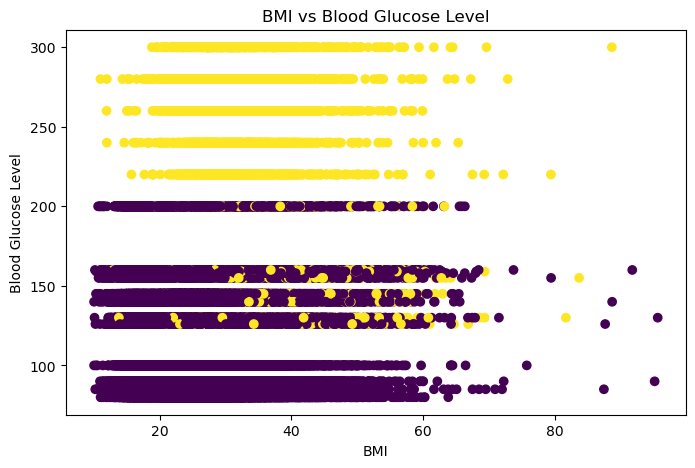

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['bmi'],
    df['blood_glucose_level'],
    c=df['diabetes']
)

plt.xlabel("BMI")

plt.ylabel("Blood Glucose Level")

plt.title("BMI vs Blood Glucose Level")

plt.show()

In [8]:
X = df.drop('diabetes', axis=1)

y = df['diabetes']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

model.fit(X_train_scaled, y_train)

KNeighborsClassifier(weights='distance')

In [12]:
y_pred = model.predict(X_test_scaled)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.95915


In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[18106   186]
 [  631  1077]]


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     18292
           1       0.85      0.63      0.73      1708

    accuracy                           0.96     20000
   macro avg       0.91      0.81      0.85     20000
weighted avg       0.96      0.96      0.96     20000



In [17]:
import os

os.makedirs("../models", exist_ok=True)

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [18]:
joblib.dump(model, "../models/knn_classifier.pkl")

joblib.dump(scaler, "../models/scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully
